# Preprocessing Discover Graph text data

In [142]:
from neo4j import GraphDatabase, basic_auth
import pandas as pd
import numpy as np
import os
import json
import collections
import sklearn
import stellargraph as sg
import nltk
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [201]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import tensorflow as tf


import stellargraph as sg
from stellargraph.mapper import FullBatchNodeGenerator
from stellargraph.layer import GAT

from tensorflow.keras import layers, optimizers, losses, metrics, Model
from sklearn import preprocessing, feature_extraction, model_selection
from stellargraph import datasets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/jpmc/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [144]:
driver = GraphDatabase.driver( "bolt://localhost:7687",  auth=basic_auth("neo4j", "nindoo123"))

# Pre-Processing Text

In [176]:
pulling_query = """\
            MATCH (a:Text)
            WHERE EXISTS (a.label)
            RETURN ID(a) AS ID, a.description AS description
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    blogs_desc = pd.DataFrame([dict(row) for row in result])
print("Shape",blogs_desc.shape)
blogs_desc.head()

Shape (344, 2)


,ID,description
0,397,We can adapt probabilistic arguments such as t...
1,410,Autonomous Formula 1 Racing using Reinforcemen...
2,414,"Where to find free lectures, seminars and comp..."
3,418,Analysis of posterior using deep neural networ...
4,430,Many people fear that robots and artificial in...


In [177]:
pulling_query = """\
            MATCH (a:INTEREST)
            WHERE EXISTS (a.label) 
            RETURN ID(a) AS ID, a.description AS description
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    interests_desc = pd.DataFrame([dict(row) for row in result])
print("Shape",interests_desc.shape)
interests_desc.head()

Shape (724, 2)


,ID,description
0,0,Web development is the work involved in develo...
1,1,TypeScript is an open-source programming langu...
2,2,A programming language is a formal language co...
3,3,Not Found
4,4,"The career is an individual's metaphorical ""jo..."


In [178]:
descriptions_db = pd.concat([blogs_desc,interests_desc])
descriptions_db['description'].str.encode('utf-8')
print(descriptions_db.shape)
descriptions_db.head()

(1068, 2)


,ID,description
0,397,We can adapt probabilistic arguments such as t...
1,410,Autonomous Formula 1 Racing using Reinforcemen...
2,414,"Where to find free lectures, seminars and comp..."
3,418,Analysis of posterior using deep neural networ...
4,430,Many people fear that robots and artificial in...


In [179]:
corpus_text = ""
for index,r in descriptions_db.iterrows():
    corpus_text += r['description']
with open('data/corpus.txt','w') as t:
    t.write(corpus_text)
    t.close()

In [228]:
processed_corpus = corpus_text.translate ({ord(c): " " for c in "',!@#$%^&*()[]{};:,./<>?\|`~-=_+"})
list_corpus = corpus_text.split(' ')
stop_words = set(nltk.corpus.stopwords.words('english'))   
  
filtered_sentence = [w for w in list_corpus if not w in stop_words]
filtered_sentence = list(filter(None,filtered_sentence))
tagged = nltk.pos_tag(filtered_sentence)
print(len(filtered_sentence))
filtered = []
for i in range(len(filtered_sentence)):
    if tagged[i][1] in ['NN','NNS','NNP','NNPS','VB','VBD','VBG','VBP','VBZ']:
        filtered.append(filtered_sentence[i])
print(len(filtered))
list_corpus = filtered



83194
55943


In [224]:
tags =[]
for i in range(len(tagged)):
    tags.append(tagged[i][1])
from collections import Counter

Counter(tags)

Counter({'PRP': 454,
         'VBP': 3236,
         'JJ': 15104,
         'NNS': 7658,
         'NNP': 12054,
         'NN': 23777,
         'CD': 2162,
         'VBG': 3046,
         'VBZ': 1809,
         'VBD': 3419,
         'VB': 812,
         'IN': 1875,
         'DT': 1073,
         'RB': 3237,
         'CC': 77,
         'MD': 403,
         'JJR': 226,
         'VBN': 1911,
         'RBR': 88,
         'FW': 130,
         'NNPS': 132,
         'TO': 18,
         'JJS': 204,
         'PRP$': 43,
         ':': 16,
         'WRB': 29,
         'EX': 50,
         'WDT': 7,
         '$': 17,
         'PDT': 16,
         'WP$': 13,
         'WP': 13,
         '(': 14,
         'RBS': 10,
         'POS': 17,
         ')': 3,
         'RP': 30,
         ',': 5,
         '.': 3,
         'SYM': 2,
         "''": 1})

In [229]:
vocab = list(set(list_corpus)) # This works well for a very small corpus
print(vocab)

ns,', 'deceive.', 'condition,', 'entertainment', 'Plotly', 'essay', 'impacts', 'Compensation', 'shops;', 'Learn', 'Between', 'Sunrise', 'operation.', '("Collision', 'instructions,', 'Jean', 'remained', 'Market,', 'player', 'coders,', 'aunt,', 'adaptation', 'compromising', 'Instant', 'improvement', 'Madurese,', 'backends,', 'Tesla,', 'interviewing', 'Eckhart', "Beginner's", 'License.', 'astronomer,', 'deviation,', 'From', 'universal.', 'CD', '(IT', 'trades', 'P(X,Y)}\n', 'region.', 'users,', 'years!\nHis', 'Software', 'birds,', 'users.', 'CAD', 'Institute', '(UI)', 'changed.', 'Independence.', 'facilitator', '"End', 'population,', 'continent.', 'ethics', 'carried', 'storing', 'multimedia', 'given,', 'volumes', 'Stack', 'jail', 'Scienc...Create', 'posted', 'example:', 'interview.', '\nthis', 'culture', 'Ferguson,', 'Garage', 'Shor', '"film"', 'COBOL,', 'convert,', 'attracts', 'cues', 'Zürich', 'language', 'creativity', 'small,', 'triangles', 'overriding', 'database)', 'jobs', 'maintainin

In [391]:
word_counter = collections.Counter()
for term in list_corpus:
    word_counter.update({term: 1})
vocab = word_counter.most_common(200) # 200 Most common terms
print('Vocab Size: {}'.format(len(vocab))) 
print(word_counter.most_common(100))

Vocab Size: 200
[('data', 421), ('software', 224), ('use', 206), ('computer', 198), ('Continue', 184), ('including', 179), ('reading', 174), ('design', 173), ('system', 164), ('\n', 164), ('include', 148), ('development', 145), ('language', 145), ('using', 143), ('learning', 141), ('programming', 138), ('used', 130), ('time', 130), ('web', 129), ('term', 129), ('systems', 127), ('machine', 122), ('United', 117), ('research', 111), ('process', 107), ('part', 105), ('information', 103), ('people', 102), ('control', 98), ('form', 98), ('application', 96), ('series', 89), ('science', 87), ('developed', 87), ('code', 86), ('analysis', 84), ('Google', 78), ('methods', 78), ('model', 77), ('state', 76), ('applications', 73), ('study', 73), ('operating', 73), ('Data', 72), ('game', 72), ('languages', 71), ('number', 70), ('computing', 70), ('field', 69), ('work', 68), ('management', 67), ('called', 67), ('business', 66), ('service', 65), ('services', 65), ('range', 64), ('became', 63), ('datab

In [392]:
vocab.append(('UNKNOWN', 1))
Idx = range(1, len(vocab)+1)
vocab = [t[0] for t in vocab]

Word2Idx = dict(zip(vocab, Idx))
Idx2Word = dict(zip(Idx, vocab))

Word2Idx['PAD'] = 0
Idx2Word[0] = 'PAD'
VOCAB_SIZE = len(Word2Idx)
print('Word2Idx Size: {}'.format(len(Word2Idx)))
print('Idx2Word Size: {}'.format(len(Idx2Word)))

Word2Idx Size: 202
Idx2Word Size: 202


In [393]:
with open('data/word2idx.json','w') as w:
    json.dump(Word2Idx,w)
with open('data/idx2word.json','w') as w:
    json.dump(Idx2Word,w)

In [394]:
w2idx_db = descriptions_db.copy()

In [395]:
features_length = 200
w2idx_dict = {}
for index,r in w2idx_db.iterrows():
    processed = r['description'].translate ({ord(c): " " for c in "''!@#$%^&*()[]{};:,./<>?\|`~-=_+"})
    list_doc = processed.split(' ')
    w2i_list = []
    for element in list_doc:
        if element in Word2Idx:
             w2i_list.append(Word2Idx[element])
        else: 
            w2i_list.append(Word2Idx['UNKNOWN'])
    while len(w2i_list) < features_length:
       w2i_list.append(Word2Idx['PAD'])
    if len(w2i_list) > features_length:
        w2i_list = w2i_list[:features_length]
    w2idx_dict[r['ID']] = w2i_list


# Creating StellarGraph

### Puxando Edges

In [396]:
pulling_query = """\
            MATCH (a)-->(b)
            WHERE EXISTS (a.label) AND EXISTS (b.label)
            RETURN ID(a) AS source, ID(b) AS target
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    edges_db = pd.DataFrame([dict(row) for row in result])
print(edges_db.shape)
edges_db.head()

(2852, 2)


,source,target
0,0,22
1,0,21
2,0,20
3,1,318
4,1,2


### puxando labels

In [397]:
pulling_query = """\
            MATCH (a)
            WHERE EXISTS (a.label)
            RETURN ID(a) AS source, a.label AS subject
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    label_db = pd.DataFrame([dict(row) for row in result])
labels = pd.Series(data =label_db['subject'].values, index = label_db['source'].values)
print(labels.shape)
labels.head()

(1068,)


0    Programming
1    Programming
2    Programming
3    Programming
4         Design
dtype: object

### cirando banco de dados de features w2idx

In [406]:
features_db = pd.DataFrame.from_dict(w2idx_dict,orient='index')
print(features_db.shape)
features_db.head()

(1068, 200)


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
397,201,201,201,201,201,201,201,201,201,201,...,0,0,0,0,0,0,0,0,0,0
410,201,201,201,201,14,201,201,5,7,201,...,0,0,0,0,0,0,0,0,0,0
414,201,201,201,201,201,201,201,201,201,201,...,0,0,0,0,0,0,0,0,0,0
418,201,201,201,14,201,201,106,5,7,201,...,0,0,0,0,0,0,0,0,0,0
430,201,28,201,201,201,201,201,71,201,129,...,0,0,0,0,0,0,0,0,0,0


### Criando grafo

In [407]:
graph = sg.StellarGraph(nodes = {"blog":features_db}, edges =  edges_db)
print(graph.info())

StellarGraph: Undirected multigraph
 Nodes: 1068, Edges: 2852

 Node types:
  blog: [1068]
    Features: float32 vector, length 200
    Edge types: blog-default->blog

 Edge types:
    blog-default->blog: [2852]
        Weights: all 1 (default)
        Features: none


In [408]:
train_subjects, test_subjects = model_selection.train_test_split(
    labels, train_size=140, test_size=None, stratify=labels
)
val_subjects, test_subjects = model_selection.train_test_split(
    test_subjects, train_size=500, test_size=None, stratify=test_subjects
)

646     Programming
680     Programming
542     Programming
1108    Programming
975     Programming
           ...     
1005             ML
602     Programming
714              ML
798     Programming
659              AI
Length: 500, dtype: object


In [409]:
from collections import Counter

Counter(train_subjects)


Counter({'Programming': 63,
         'ML': 29,
         'AI': 9,
         'Education': 8,
         'Design': 11,
         'Society': 20})

In [410]:
target_encoding = preprocessing.LabelBinarizer()

train_targets = target_encoding.fit_transform(train_subjects)
val_targets = target_encoding.transform(val_subjects)
test_targets = target_encoding.transform(test_subjects)
#print(train_targets)

In [411]:
generator = FullBatchNodeGenerator(graph, method="gat")

train_gen = generator.flow(train_subjects.index, train_targets)

In [412]:
gat = GAT(
    layer_sizes=[8,train_targets.shape[1]],
    activations=["elu", "softmax"],
    attn_heads=8,
    generator=generator,
    in_dropout=0.5,
    attn_dropout=0.5,
    normalize=None,
)

In [413]:
x_inp, predictions = gat.in_out_tensors()

In [414]:
model = Model(inputs=x_inp, outputs=predictions)
model.compile(
    optimizer=optimizers.Adam(lr=0.005),
    loss=losses.categorical_crossentropy,
    metrics=["acc"],
)

In [415]:
val_gen = generator.flow(val_subjects.index, val_targets)

In [416]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

if not os.path.isdir("logs"):
    os.makedirs("logs")
es_callback = EarlyStopping(
    monitor="val_acc", patience=100
)  # patience is the number of epochs to wait before early stopping in case of no further improvement
mc_callback = ModelCheckpoint(
    "models/best_model.h5", monitor="val_acc", save_best_only=True, save_weights_only=False
)

In [417]:
model.summary()

Model: "model_20"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_53 (InputLayer)           [(1, 1068, 200)]     0                                            
__________________________________________________________________________________________________
input_55 (InputLayer)           [(1, None, 2)]       0                                            
__________________________________________________________________________________________________
input_56 (InputLayer)           [(1, None)]          0                                            
__________________________________________________________________________________________________
dropout_26 (Dropout)            (1, 1068, 200)       0           input_53[0][0]                   
___________________________________________________________________________________________

In [418]:
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    verbose=2,
    shuffle=False,  # this should be False, since shuffling data means shuffling the whole graph
    callbacks=[mc_callback],
)

Epoch 1/30
1/1 - 0s - loss: 11.1996 - acc: 0.2286 - val_loss: 9.0847 - val_acc: 0.4160
Epoch 2/30
1/1 - 0s - loss: 8.8697 - acc: 0.3143 - val_loss: 9.2501 - val_acc: 0.4100
Epoch 3/30
1/1 - 0s - loss: 11.0340 - acc: 0.2857 - val_loss: 8.4247 - val_acc: 0.4580
Epoch 4/30
1/1 - 0s - loss: 10.5019 - acc: 0.2643 - val_loss: 8.7598 - val_acc: 0.4520
Epoch 5/30
1/1 - 0s - loss: 10.3734 - acc: 0.2857 - val_loss: 8.8327 - val_acc: 0.4520
Epoch 6/30
1/1 - 0s - loss: 9.9985 - acc: 0.3071 - val_loss: 8.8196 - val_acc: 0.4520
Epoch 7/30
1/1 - 0s - loss: 9.0724 - acc: 0.3786 - val_loss: 8.8327 - val_acc: 0.4520
Epoch 8/30
1/1 - 0s - loss: 8.2299 - acc: 0.4000 - val_loss: 8.8021 - val_acc: 0.4520
Epoch 9/30
1/1 - 0s - loss: 10.5794 - acc: 0.2786 - val_loss: 8.8327 - val_acc: 0.4520
Epoch 10/30
1/1 - 0s - loss: 8.5592 - acc: 0.3929 - val_loss: 8.8327 - val_acc: 0.4520
Epoch 11/30
1/1 - 0s - loss: 8.5399 - acc: 0.3714 - val_loss: 8.8327 - val_acc: 0.4520
Epoch 12/30
1/1 - 0s - loss: 9.7329 - acc: 0.35

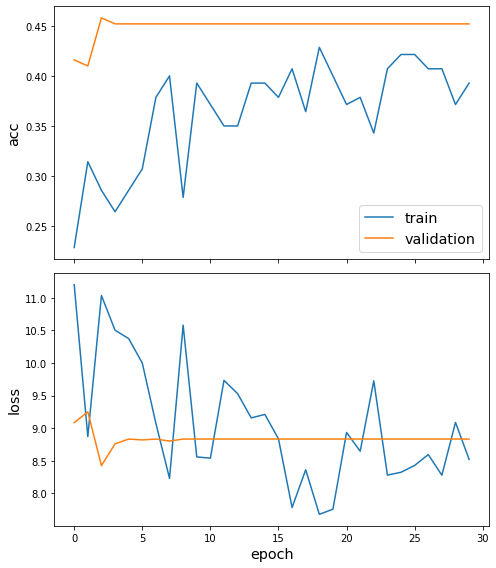

In [419]:
sg.utils.plot_history(history)

In [420]:
test_gen = generator.flow(test_subjects.index, test_targets)
test_metrics = model.evaluate(test_gen)
print("\nTest Set Metrics:")
for name, val in zip(model.metrics_names, test_metrics):
    print("\t{}: {:0.4f}".format(name, val))

1/1 [==============================] - 0s 980us/step - loss: 8.8122 - acc: 0.4533

Test Set Metrics:
	loss: 8.8122
	acc: 0.4533


In [421]:
all_nodes = labels.index
all_gen = generator.flow(all_nodes)
all_predictions = model.predict(all_gen)

In [422]:
node_predictions = target_encoding.inverse_transform(all_predictions.squeeze())

In [423]:
df = pd.DataFrame({"Predicted": node_predictions, "True": labels})
df.head(20)

,Predicted,True
0,Programming,Programming
1,Programming,Programming
2,Programming,Programming
3,Programming,Programming
4,Programming,Design
5,Programming,Society
6,Programming,Education
7,Programming,Society
8,Programming,Design
9,Programming,Education


### Embeddings

In [424]:
emb_layer = next(l for l in model.layers if l.name.startswith("graph_attention"))
print(
    "Embedding layer: {}, output shape {}".format(emb_layer.name, emb_layer.output_shape)
)

Embedding layer: graph_attention_sparse_26, output shape (1, 1068, 64)


In [425]:
embedding_model = Model(inputs=x_inp, outputs=emb_layer.output)
emb = embedding_model.predict(all_gen)
X = emb.squeeze()
y = np.argmax(target_encoding.transform(labels), axis=1)

In [426]:
if X.shape[1] > 2:
    transform = TSNE  # PCA

    trans = transform(n_components=2)
    emb_transformed = pd.DataFrame(trans.fit_transform(X), index=list(graph.nodes()))
    emb_transformed["label"] = y
else:
    emb_transformed = pd.DataFrame(X, index=list(G.nodes()))
    emb_transformed = emb_transformed.rename(columns={"0": 0, "1": 1})
    emb_transformed["label"] = y

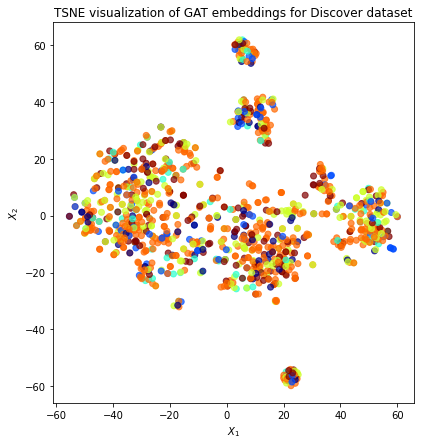

In [427]:
alpha = 0.7

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    emb_transformed[0],
    emb_transformed[1],
    c=emb_transformed["label"].astype("category"),
    cmap="jet",
    alpha=alpha,
)
ax.set(aspect="equal", xlabel="$X_1$", ylabel="$X_2$")
plt.title(
    "{} visualization of GAT embeddings for Discover dataset".format(transform.__name__)
)
plt.show()